In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load the dataset
df = pd.read_csv("C:/Users/LOQ/Downloads/archive/stock_data.csv", index_col=0, parse_dates=True)

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

# Display the entire DataFrame
#print(df)

# ----------------------------
# Choose a stock to predict (e.g., 'Stock_1')
# ----------------------------

stock_column = 'Stock_1'
data = df[[stock_column]].copy()
data.columns = ['Close']  # rename for consistency

# ----------------------------
# Create features using lag values (previous day's prices)
# ----------------------------

data['Open'] = data['Close'].shift(1)
data['High'] = data['Close'].rolling(2).max().shift(1)
data['Low'] = data['Close'].rolling(2).min().shift(1)
data['Volume'] = np.random.randint(1e6, 5e6, size=len(data))  # Mock Volume

# Target is next day's close price
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaNs from lagging
data.dropna(inplace=True)

# ----------------------------
# Train-Test Split
# ----------------------------

X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Target']

split_index = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Train Model


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)



In [22]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 7.01


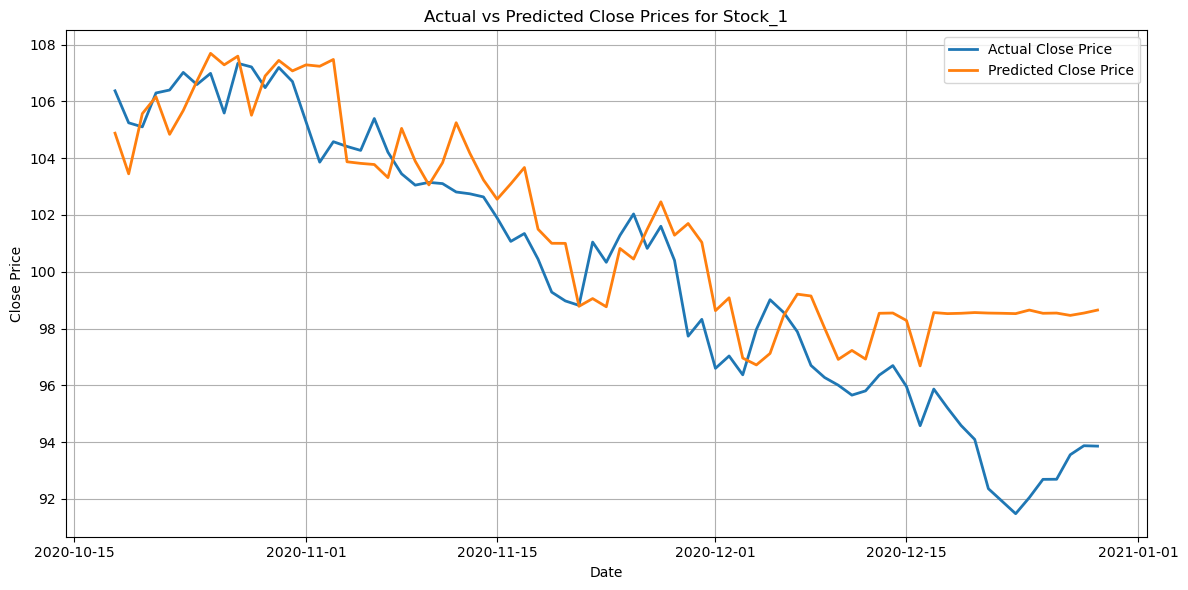

In [18]:
# ----------------------------
# Plot Actual vs Predicted
# ----------------------------

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Close Price', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted Close Price', linewidth=2)
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title(f"Actual vs Predicted Close Prices for {stock_column}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()